# Importing and Loading Datases

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('advertising.csv')

# Describing Datasets

## Printing Dimensions

In [ ]:
print(f"No. of Rows : {df.shape[0]}\nNo. of Columns : {df.shape[1]}")

No. of Rows : 400
No. of Columns : 3


## Printing Columns

In [ ]:
df.columns

Index(['Age', 'EstimatedSalary', 'Purchased'], dtype='object')

## Printing Sample 5 Rows

In [ ]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


## Printing Statistical Details

In [ ]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


# Cleaning Data

In [ ]:
missing_values = df.isnull().sum()
print("Missing Values Count:\n", missing_values)

Missing Values Count:
 Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


# Splitting the Dataset

In [ ]:
X = df.iloc[:, [0, 1]].values
y = df.iloc[:, -1].values

# Feature Scaling

## Splitting into 75% Training Dataset

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

# Testing Model

In [ ]:
y_pred = model.predict(X_test)

## Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix : \n{cm}")

Confusion Matrix : 
[[65  3]
 [ 8 24]]


## Accuracy Score

In [ ]:
from sklearn.metrics import accuracy_score
print(f"Accuracy Score : {accuracy_score(y_pred, y_test)}")

Accuracy Score : 0.89


# Visulization

## Visualizing Training Set Result

<ipython-input-22-22ba72140c86>:21: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


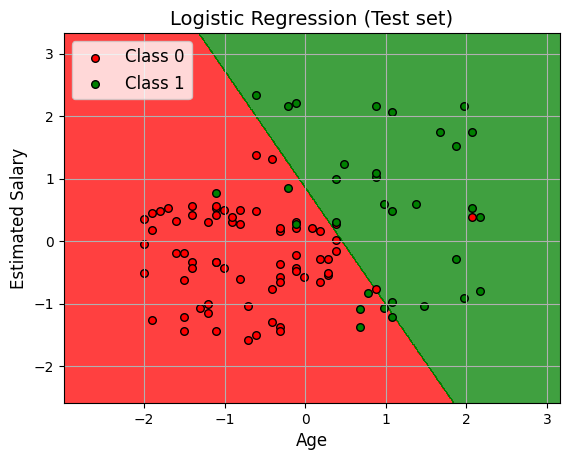

In [ ]:
X_set, y_set = X_test, y_test  # Now using the test set
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1,
                               stop = X_set[:, 0].max() + 1,
                               step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1,
                               stop = X_set[:, 1].max() + 1,
                               step = 0.01))

Z = model.predict(np.array([X1.ravel(), X2.ravel()]).T)
Z = Z.reshape(X1.shape)

cmap = ListedColormap(('red', 'green'))

plt.contourf(X1, X2, Z, alpha=0.75, cmap=cmap)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# Plotting the test set points
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c=cmap(i), label=f'Class {j}', edgecolor='black', s=30)

plt.title('Logistic Regression (Test set)', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Estimated Salary', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True)
plt.show()

## Visualizing Testing Set Result

<ipython-input-21-5ae574a6d84f>:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


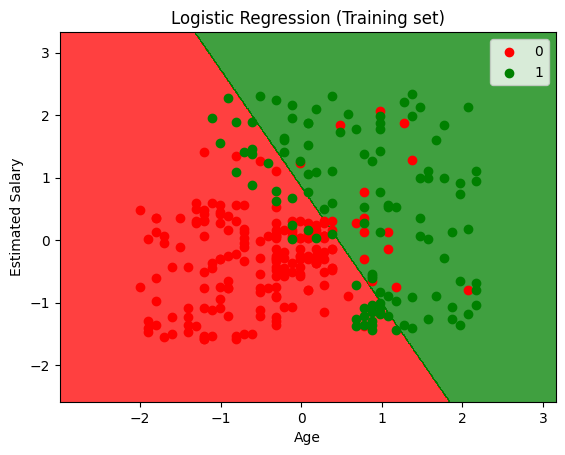

In [ ]:
# Step 1: Prepare the mesh grid
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))

# Step 2: Plot the decision boundary
plt.contourf(X1, X2, Z, alpha=0.75, cmap=cmap)


# Step 3: Set the limits of the plot
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# Step 4: Scatter plot of the training set results
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)

# Step 5: Add title and labels
plt.title('Logistic Regression (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')

# Step 6: Add legend
plt.legend()

# Step 7: Show the plot
plt.show()
